In [11]:
import numpy as np
!pip install -Uq pymcel
!pip install -Uq rebound pandas plotly nbformat

In [7]:
import pymcel as pc

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [ ]:
# tabla, jd, X = pc.consulta_horizons(id ='399', location = '@SSB', epochs = '2026-2-26')
# r_tierra = X[0 : 3]

In [ ]:
# tabla, jd, X = pc.consulta_horizons(id = '0', location = '@SSB', epochs = '2026-2-26')
# r_sol = X[0 : 3]

In [13]:
# # Obtener posición y velocidad del Sol "hoy" usando pymcel y HORIZONS

# # Consultamos HORIZONS para la fecha actual (sistema UTC) en el baricentro del sistema solar
# tabla_hoy, jd_hoy, X_hoy = pc.consulta_horizons(
#     id='10',          # 10 = Sol en HORIZONS
#     location='@SSB',  # Baricentro del Sistema Solar
#     epochs='now'      # Fecha y hora actuales
# )

# # X_hoy contiene [x, y, z, vx, vy, vz]
# r_sol_hoy = X_hoy[0:3]   # Posición (m)
# v_sol_hoy = X_hoy[3:6]   # Velocidad (m/s)

# r_sol_hoy, v_sol_hoy, jd_hoy

In [ ]:
#utiliza pymcel para obtener la posición y velocidad del Sol en el baricentro del sistema solar para la fecha actual, usa la rutina consulta_horizons 

In [16]:
tabla, jd, X_sol = pc.consulta_horizons(
    id = 'sun',
    location = '@SSB',
    epochs = '2026-2-26 00:00:00'
    )
X_sol

array([-3.99267884e+08, -8.24090450e+08,  1.85429947e+07,  1.22108229e+01,
        1.23932702e+00, -2.42604119e-01])

In [17]:
# Usamos consulta_horizons para obtener la posición de Júpiter (barycenter) en el baricentro del SS
# en la misma fecha del ejemplo (mismo jd que ya tenemos)

tabla_jup, jd_jup, X_jup = pc.consulta_horizons(
    id='5',           # 5 = Jupiter barycenter en HORIZONS
    location='@SSB',  # Baricentro del Sistema Solar
    epochs=jd         # Usamos el mismo JD que ya tenemos definido
)

# X_jup: [x, y, z, vx, vy, vz] en unidades de HORIZONS (m y m/s)
r_jupiter = X_jup[0:3]   # posición
v_jupiter = X_jup[3:6]   # velocidad

r_jupiter, v_jupiter

(array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]),
 array([-12125.37715192,  -4618.63890634,    290.51092555]))

In [18]:
r_sol_0= X_sol[:3] 
v_sol_0= X_sol[3:]
r_jup_0= X_jup[:3]
v_jup_0= X_jup[3:]

In [21]:
deltat = 1 * 86400 # 1 día en segundos
r_jup_dt = r_jup_0 + v_jup_0 * deltat
r_sol_dt = r_sol_0 + v_sol_0 * deltat

r_jup_dt, r_jup_0 #esto es para el calculo de la posicion de júpiter

(array([-3.14547192e+11,  7.16132604e+11,  4.06889651e+09]),
 array([-3.13499559e+11,  7.16531655e+11,  4.04379637e+09]))

In [24]:
# ahora debemos obtener la velocidad de jupiter desde pues de un dt
mu_sol = pc.constantes.mu_sun # m^3/s^2
mu_jup = pc.constantes.mu_jupiter # m^3/s^2
rij_vec = r_jup_0 - r_sol_0
v_jup_dt = v_jup_0 - mu_sol * rij_vec / np.linalg.norm(rij_vec)**3 * deltat
v_jup_dt

array([-12117.89040582,  -4635.79206931,    290.41467508])

In [23]:
# Calculamos la velocidad del Sol después de un intervalo de tiempo deltat,
# usando la aceleración debida a la gravedad de Júpiter

# Vector desde el Sol hacia Júpiter en t0
r_sj_vec = r_jup_0 - r_sol_0

# Actualizamos la velocidad del Sol (aprox. Euler explícito)
v_sol_dt = v_sol_0 + mu_jup * r_sj_vec / np.linalg.norm(r_sj_vec)**3 * deltat

v_sol_dt

array([12.2036746 ,  1.25570472, -0.24251222])

In [ ]:
import matplotlib.pyplot as plt

# Número de años y pasos (1 paso = 1 día, ya tienes deltat = 1 día en segundos)
n_years = 12
days_per_year = 365  # aproximación
n_steps = n_years * days_per_year

# Copias de las condiciones iniciales
r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

# Listas para guardar trayectorias
r_sol_traj = []
r_jup_traj = []

for _ in range(n_steps):
    # Guardar posición actual
    r_sol_traj.append(r_sol.copy())
    r_jup_traj.append(r_jup.copy())
    
    # Vector desde Sol a Júpiter
    rij = r_jup - r_sol
    dist = np.linalg.norm(rij)
    
    # Aceleraciones (solo interacción mutua Sol-Júpiter)
    a_jup = -mu_sol * rij / dist**3          # aceleración de Júpiter por el Sol
    a_sol =  mu_jup * rij / dist**3          # aceleración del Sol por Júpiter
    
    # Integración tipo Euler explícito
    v_jup = v_jup + a_jup * deltat
    v_sol = v_sol + a_sol * deltat
    
    r_jup = r_jup + v_jup * deltat
    r_sol = r_sol + v_sol * deltat

r_sol_traj = np.array(r_sol_traj)
r_jup_traj = np.array(r_jup_traj)

# Gráfica en el plano xy
plt.figure(figsize=(8, 8))
plt.plot(r_sol_traj[:, 0], r_sol_traj[:, 1], label="Sol", color="orange")
plt.plot(r_jup_traj[:, 0], r_jup_traj[:, 1], label="Júpiter", color="tab:blue")

# Marcar posiciones iniciales
plt.scatter(r_sol_traj[0, 0], r_sol_traj[0, 1], color="red", s=50, label="Sol (inicio)")
plt.scatter(r_jup_traj[0, 0], r_jup_traj[0, 1], color="green", s=50, label="Júpiter (inicio)")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbitas Sol–Júpiter (integración 12 años, paso 1 día)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

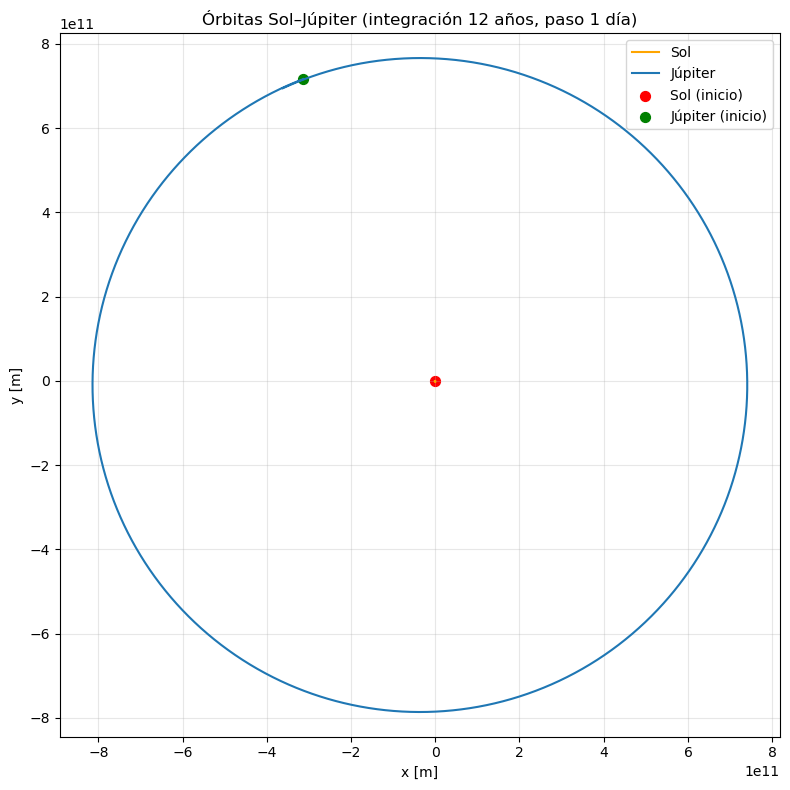

In [25]:
import matplotlib.pyplot as plt

# Número de años y pasos (1 paso = 1 día, ya tienes deltat = 1 día en segundos)
n_years = 12
days_per_year = 365  # aproximación
n_steps = n_years * days_per_year

# Copias de las condiciones iniciales
r_sol = r_sol_0.copy()
v_sol = v_sol_0.copy()
r_jup = r_jup_0.copy()
v_jup = v_jup_0.copy()

# Listas para guardar trayectorias
r_sol_traj = []
r_jup_traj = []

for _ in range(n_steps):
    # Guardar posición actual
    r_sol_traj.append(r_sol.copy())
    r_jup_traj.append(r_jup.copy())
    
    # Vector desde Sol a Júpiter
    rij = r_jup - r_sol
    dist = np.linalg.norm(rij)
    
    # Aceleraciones (solo interacción mutua Sol-Júpiter)
    a_jup = -mu_sol * rij / dist**3          # aceleración de Júpiter por el Sol
    a_sol =  mu_jup * rij / dist**3          # aceleración del Sol por Júpiter
    
    # Integración tipo Euler explícito
    v_jup = v_jup + a_jup * deltat
    v_sol = v_sol + a_sol * deltat
    
    r_jup = r_jup + v_jup * deltat
    r_sol = r_sol + v_sol * deltat

r_sol_traj = np.array(r_sol_traj)
r_jup_traj = np.array(r_jup_traj)

# Gráfica en el plano xy
plt.figure(figsize=(8, 8))
plt.plot(r_sol_traj[:, 0], r_sol_traj[:, 1], label="Sol", color="orange")
plt.plot(r_jup_traj[:, 0], r_jup_traj[:, 1], label="Júpiter", color="tab:blue")

# Marcar posiciones iniciales
plt.scatter(r_sol_traj[0, 0], r_sol_traj[0, 1], color="red", s=50, label="Sol (inicio)")
plt.scatter(r_jup_traj[0, 0], r_jup_traj[0, 1], color="green", s=50, label="Júpiter (inicio)")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Órbitas Sol–Júpiter (integración 12 años, paso 1 día)")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

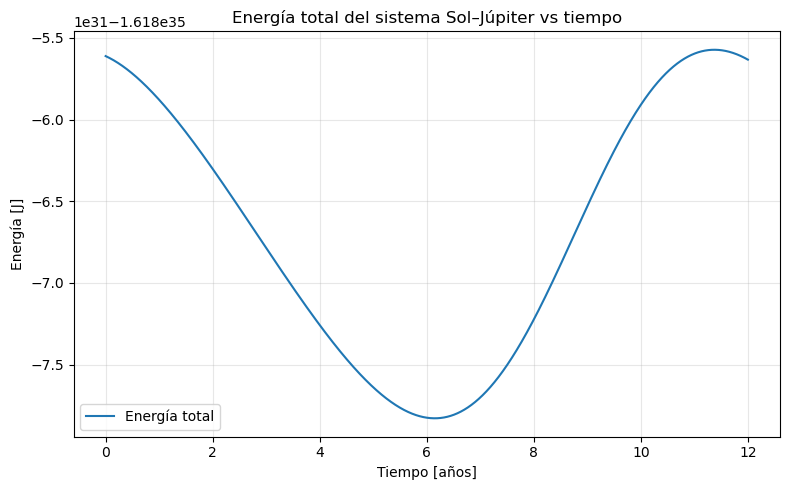

In [28]:
# Cálculo y gráfico de la energía (cinética + potencial) como función del tiempo

# Masas a partir de los parámetros gravitacionales mu = G*M
G = pc.constantes.G  # constante de gravitación universal en SI
M_sol = mu_sol / G
M_jup = mu_jup / G

# --- Reconstruir velocidades a lo largo de la integración -----------------
# A partir de las posiciones y las ecuaciones de movimiento:
#   a_jup = -mu_sol * rij / |rij|^3
#   a_sol =  mu_jup * rij / |rij|^3
# Integramos por Euler hacia adelante para obtener v(t) de nuevo

n_steps = r_sol_traj.shape[0]

v_sol_rec = np.zeros_like(r_sol_traj)
v_jup_rec = np.zeros_like(r_jup_traj)

# condiciones iniciales conocidas
v_sol_rec[0] = v_sol_0
v_jup_rec[0] = v_jup_0

for k in range(n_steps - 1):
    rij_k = r_jup_traj[k] - r_sol_traj[k]
    dist_k = np.linalg.norm(rij_k)
    a_jup_k = -mu_sol * rij_k / dist_k**3
    a_sol_k =  mu_jup * rij_k / dist_k**3

    v_jup_rec[k+1] = v_jup_rec[k] + a_jup_k * deltat
    v_sol_rec[k+1] = v_sol_rec[k] + a_sol_k * deltat

# --- Energía total en cada paso ------------------------------------------
# Energía cinética
KE_sol = 0.5 * M_sol * np.sum(v_sol_rec**2, axis=1)
KE_jup = 0.5 * M_jup * np.sum(v_jup_rec**2, axis=1)
KE_tot = KE_sol + KE_jup

# Energía potencial gravitacional (dos cuerpos)
rij_all = r_jup_traj - r_sol_traj
dist_all = np.linalg.norm(rij_all, axis=1)
PE = -G * M_sol * M_jup / dist_all

E_tot = KE_tot + PE

# Vector de tiempo en años
t = np.arange(n_steps) * deltat / (86400 * 365.0)

plt.figure(figsize=(8, 5))
plt.plot(t, E_tot, label="Energía total")
plt.xlabel("Tiempo [años]")
plt.ylabel("Energía [J]")
plt.title("Energía total del sistema Sol–Júpiter vs tiempo")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()